## IMPORTS

In [40]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning.loggers import WandbLogger
import wandb
import optuna
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

## DATALOADERS AND MODEL

In [41]:
df = pd.read_csv("data/carbon_data.csv")
df.drop(columns=["user_id"], inplace=True)

df.head()

,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


In [42]:
target = "carbon_footprint_kg"
categorical_cols = ["day_type", "transport_mode", "food_type", "eco_actions"]
numerical_cols = ["distance_km", "electricity_kwh", "renewable_usage_pct", "screen_time_hours", "waste_generated_kg"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(sparse_output=False), categorical_cols)
])
X = preprocessor.fit_transform(df[categorical_cols + numerical_cols])
y = df[target].values.astype(float)



X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=420
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=420
)


class CarbonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Regression

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CarbonDataset(X_train, y_train)
val_dataset = CarbonDataset(X_val, y_val)
test_dataset = CarbonDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


In [43]:
input_dim = X_train.shape[1]

class CarbonModel(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=64, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.mse_loss(y_hat, y)
        self.log("train_loss", loss, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.mse_loss(y_hat, y)
        self.log("val_loss", loss, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.mse_loss(y_hat, y)
        self.log("test_loss", loss, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [44]:
class CarbonDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, test_dataset, batch_size=32):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

## TRAINING BEFORE HPO

In [45]:
wandb_logger = WandbLogger(project="carbon_footprint_prediction")

data_module = CarbonDataModule(train_dataset, val_dataset, test_dataset)
model = CarbonModel(input_dim=input_dim)

trainer = pl.Trainer(max_epochs=50, logger=wandb_logger)
trainer.fit(model, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\kalmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\loggers\wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
c:\Users\kalmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory .\carbon_footprint_prediction\3qt860iq\checkpoints exists and is not empty.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | Sequential | 5.6 K  | train | 0    
--------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kalmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\kalmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\kalmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


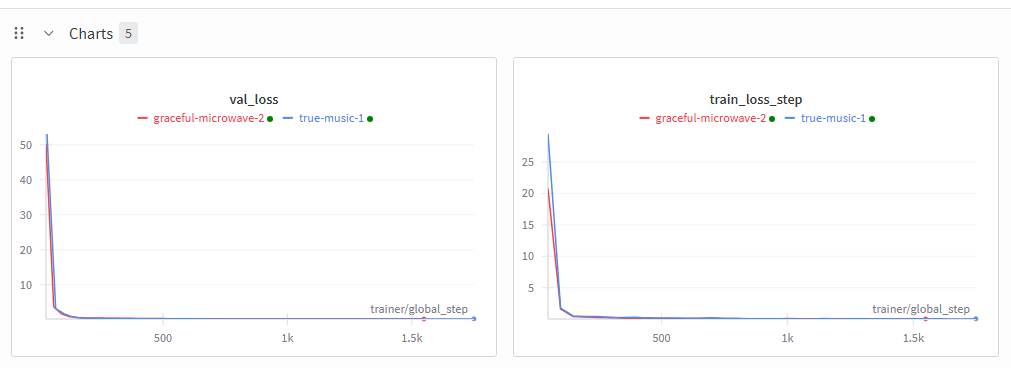

In [46]:
test_results = trainer.test(model, dataloaders=data_module.test_dataloader())
print("Test results before HPO:", test_results)

c:\Users\kalmu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.04300250485539436
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results before HPO: [{'test_loss': 0.04300250485539436}]


## HPO

In [47]:
def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 256)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    model = CarbonModel(input_dim=input_dim, hidden_dim=hidden_dim, lr=lr)
    
    early_stop_callback = EarlyStopping(monitor="val_loss", patience=5, mode="min")
    
    trainer = pl.Trainer(
        max_epochs=50,
        enable_checkpointing=False,
        logger=False,
        callbacks=[early_stop_callback],
        enable_progress_bar=False
    )
    
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
    
    val_loss = trainer.callback_metrics["val_loss"].item()
    
    return val_loss


In [48]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)  # try 20 different hyperparameter combinations

print("Best trial:")
print(study.best_trial.params)

[I 2026-01-28 03:21:49,663] A new study created in memory with name: no-name-c953a0be-9bdf-4f72-a5eb-db2e12d69ed1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | Sequential | 3.3 K  | train | 0    
-----------------------------------------------------
3.3 K     Trainable params
0         Non-trainable params
3.3 K     Total params
0.013     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops
`Trainer.fit` stopped: `max_epochs=50` reached.
[I 2026-01-28 03:21:51,075] Trial 0 finished with value: 0.038492199033498764 and parameters: {'hidden_dim': 47, 'lr': 0.0031429258596668928, 'batch_size': 64}. Best is trial 0 with value: 0.038492199033498764.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name  | Type       | Params | Mode  | FLOPs
--------

Best trial:
{'hidden_dim': 202, 'lr': 0.00973459875050493, 'batch_size': 32}


In [49]:
best_params = study.best_trial.params

train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params["batch_size"])
test_loader = DataLoader(test_dataset, batch_size=best_params["batch_size"])

final_model = CarbonModel(
    input_dim=input_dim,
    hidden_dim=best_params["hidden_dim"],
    lr=best_params["lr"]
)

trainer = pl.Trainer(max_epochs=50)
trainer.fit(final_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

test_results = trainer.test(final_model, dataloaders=test_loader)
print("Test results after HPO:", test_results)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | Sequential | 45.7 K | train | 0    
-----------------------------------------------------
45.7 K    Trainable params
0         Non-trainable params
45.7 K    Total params
0.183     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.009831002913415432
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results after HPO: [{'test_loss': 0.009831002913415432}]


In [55]:
import json

checkpoint_path = "final_model.ckpt"
trainer.save_checkpoint(checkpoint_path)

best_params["input_dim"] = input_dim

print(f"Model checkpoint saved at {checkpoint_path}")

# 2️⃣ Save best hyperparameters to a JSON file
params_path = "best_params.json"
with open(params_path, "w") as f:
    json.dump(best_params, f)

print(f"Best hyperparameters saved at {params_path}")

import joblib

# Save the fitted preprocessor
joblib.dump(preprocessor, "preprocessor.joblib")

# After training your model
torch.save(model.state_dict(), "carbon_model.pth")



`weights_only` was not set, defaulting to `False`.


Model checkpoint saved at final_model.ckpt
Best hyperparameters saved at best_params.json
